# Make an n-points-probe experiment

Using the "probes_experiment" module

Get the code: do this first / once. Assumes that import will succeed

In [1]:
!pip install git+https://github.com/nase0005/n-point-probes-.git
import probes_experiment as pe
import utils

##bindings
from utils import load_target_images_from_directory, extract_segment_count_from_filename, sample_grid_map


  Cloning https://github.com/nase0005/n-point-probes-.git to /tmp/pip-req-build-w8n6rr3q
  Running command git clone --filter=blob:none --quiet https://github.com/nase0005/n-point-probes-.git /tmp/pip-req-build-w8n6rr3q
  Resolved https://github.com/nase0005/n-point-probes-.git to commit 3e7e215036f3d6a92f58f5eec918d16979f56d71
  Preparing metadata (setup.py) ... done
  Created wheel for n_point_probes: filename=n_point_probes-0.1.0-py3-none-any.whl size=20681 sha256=9d039097d508ddcaad94291f1d3acdc3d4ed51c653b3f7cbcfa2dcb8057ea2c9
  Stored in directory: /tmp/pip-ephem-wheel-cache-8q4c_lc_/wheels/b5/59/0e/3f19d731f75c62980c658848b1b65566c0198cd7f341d2a7cf
Successfully built n_point_probes


Cumbersome, but: if you change any part of the code in the repo, you have to re-install and, hopefully, not have to restart the runtime.

In [2]:
import importlib

##grab updated repo
!pip install --upgrade --force-reinstall -q git+https://github.com/nase0005/n-point-probes-.git

##reload all the code you need
importlib.reload(pe)
importlib.reload(utils)


##re-establish the bindings
from utils import load_target_images_from_directory, extract_segment_count_from_filename, sample_grid_map, downsample_data_bundle


  Preparing metadata (setup.py) ... done


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

Mount your google drive

In [4]:
##mount the drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


You may care about your device

In [5]:
# Automatically picks CUDA (GPU) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Build the experiment

After you run this cell, you should have a folder with a
.csv file that provides exhaustive trial-by-trial info, a subfolder with all of the display stimuli, and another with the target images in various formats (for convenience).

In [6]:

##our name for the experiment. we write all assets here
experiment_id = "demo_experiment"

##my location on drive
base_dir = Path("/content/drive/MyDrive/imagery_psychophysics/cloud-of-point-probes/data/")
workspace = base_dir / "experiments" / experiment_id

##I've prepared some RGB target pictures using powerpoint. This is where they live
##The images are just curves on a blank background. One of them is split into segments of different colors.
target_images = load_target_images_from_directory(base_dir / "squiggle_pics")


##These are my experimental parameters.
num_vision_trials = 5
num_imagery_trials = 10
sampling_policy = pe.ProbeSubsetPolicy.VISION_SUBSET_OF_IMAGERY ##this tells the probe generator how to select vision trials
randomization_seed = 123

##you may want to designate a target image
curve_segment_id = 1

##some display parameters
probe_color = (255, 105, 180, 255)
probe_radius = 6
background_color = (10, 10, 10, 255)

##we currently support each of these as our potential statistic of interest
metrics = ["object_count", "touches_per_segment", "target_object_hits"] ##see ProbeMaskAnalyzer for choices

##currently you need to decide up front your sampling resolution. this will impact the resolution of your post-hoc analyses
grid_shape = (20, 20)

##how many points in your probe
points_per_probe = 2

##currently I explicitly put the number of segments in each image into the filename. there are other ways to do this.
for target_image in target_images:
    n_segments = extract_segment_count_from_filename(target_image.name, default=4)
    ##because our target images are RGB, we need to format them explicitly as segmentations. Obviously, this approach will only work for really simple images...
    pe.TargetSegmenter.segment_kmeans(target_image, n_clusters=n_segments)

##A trial is made up of a set of runs. Each run is some number of imagery and vision trials for a single target expeirment.
##here we are fixing these numbers for each of our 3 target images
configs = [pe.RunConfig(img, num_vision_trials=num_vision_trials, num_imagery_trials=num_imagery_trials) for img in target_images]

##We package it all into a an experiment class that builds out all of Trial and Probe instance we need to make an experiment
exp = pe.Experiment.create(
    experiment_id=experiment_id,
    run_configs=configs,
    root_dir=workspace,
    probe_color=probe_color,
    probe_radius=probe_radius,
    bg_color=background_color
)

##We build probes. Currently this is very simple: if you request enough probes or a high-enough n, each point on the grid will sampled at least once
generator = pe.GridProbeGenerator(grid_shape=grid_shape, points_per_probe=points_per_probe)
for run in exp.runs:
    generator.assign_probes_to_run(run, policy=sampling_policy, seed=randomization_seed)

##Here we pre-compute ground truth for each of our desired metrics.
pe.ProbeMaskAnalyzer.evaluate_experiment_results(
    experiment=exp,
    metrics=metrics,
    target_segment_id=curve_segment_id,
)

##Make the display stimuli for the epxeriment. To check things, you can choose to print the ground truth result on the image, as we do here
pe.StimulusRenderer.render_experiment_stimuli(experiment=exp, include_ground_truth=True)

##Validate everythiing and then export priceless data
if exp.validate():
    df = exp.to_dataframe()
    df.to_csv(exp.root_dir / "trials.csv", index=False) ##create a conditions file by selecting the columns you need
    exp.export_summary_txt()
    exp.export_target_assets()
    ##this is a data bundle (dict) where all of the probes, ground truth metrics and labelmaps are vectorized. For analysis
    vec_dict = exp.to_data_bundle()

## Output folder should look like this when done

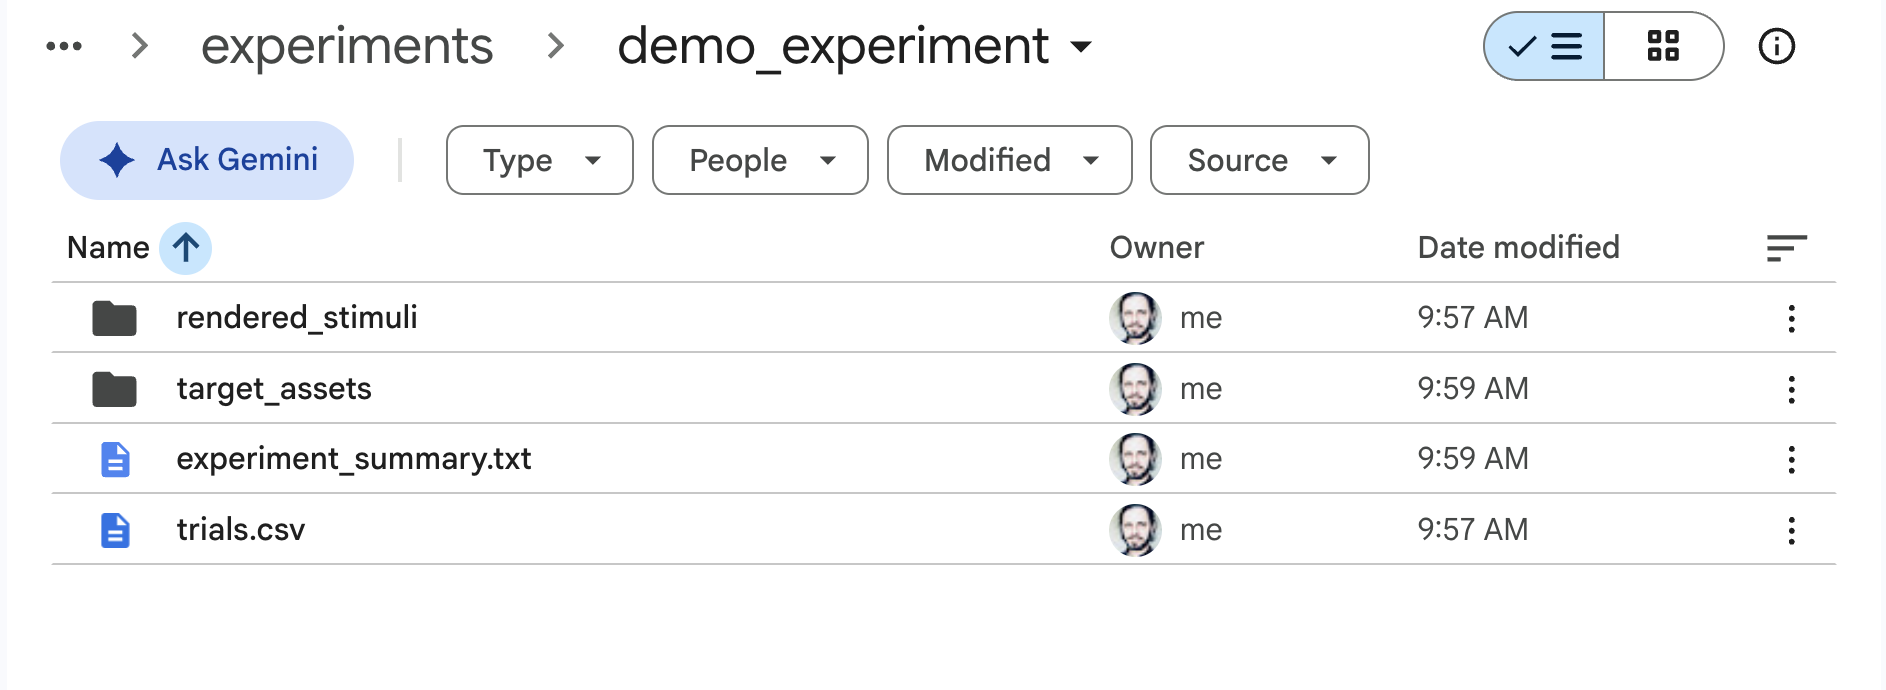

In [7]:
##if you want to downsample the label_maps and probe_masks, you can do this and it will leave the object_count data unchanged
##downsample the vec_dict data. The target images are downsampled at exactly the grid of pixels from with the probe points are sampled
low_res_data = downsample_data_bundle(vec_dict, inplace = False)

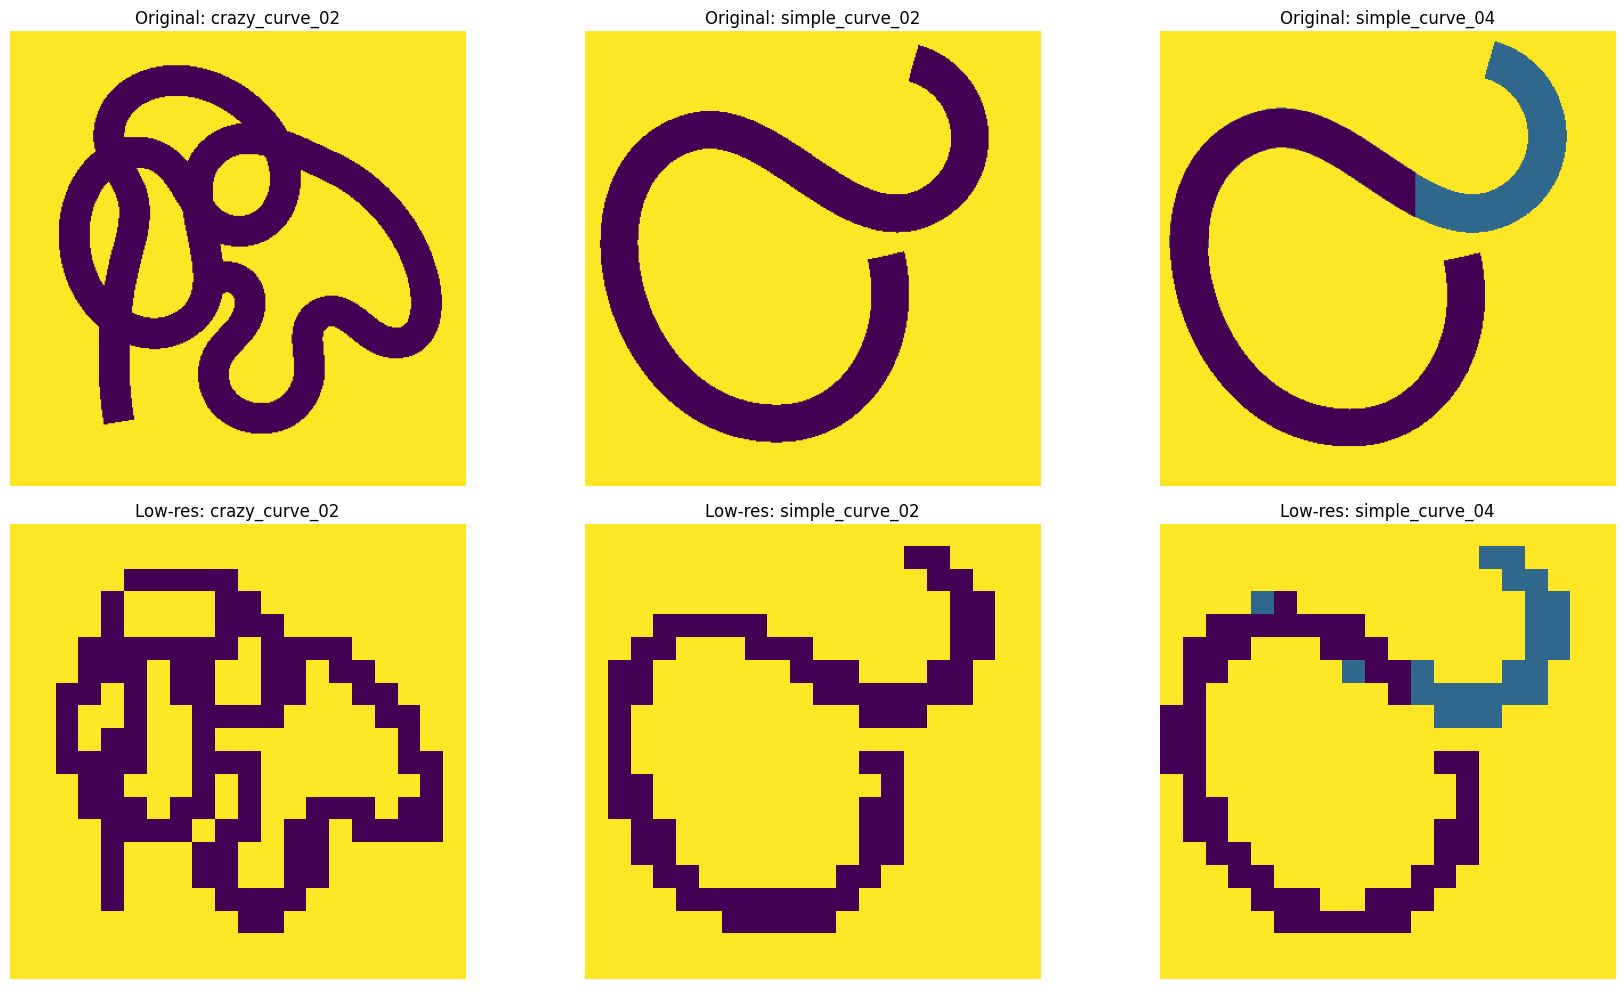

In [8]:
##here are the target images at display and downsampled resolution
num_images = len(vec_dict)

fig, axes = plt.subplots(2, num_images, figsize=(6 * num_images, 10))

# Ensure axes is always a 2D array, even if num_images is 1
if num_images == 1:
    axes = np.array([axes]).reshape(2, 1)

for i, (image_name, original_data) in enumerate(vec_dict.items()):
    original_rgba = original_data['target_assets']['label_map']
    low_res_rgba = low_res_data[image_name]['target_assets']['label_map']

    # Top row: Original images
    axes[0, i].imshow(original_rgba)
    axes[0, i].set_title(f'Original: {image_name}')
    axes[0, i].axis('off')

    # Bottom row: Low-resolution images
    axes[1, i].imshow(low_res_rgba)
    axes[1, i].set_title(f'Low-res: {image_name}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()